In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import pandas as pd
from utils.preprocess import *
import os
import sys
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper
from simulate.simulate import *
from omegaconf import OmegaConf
from utils.hydra import *
from datasets.process import *
from scripts.run_model import *
from eval.eval import *
import matplotlib.pyplot as plt
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
############################################################

In [3]:
### SETTINGS ###
config = load_config(overrides=['dataset=zebrafish'])

adata = process_data(pc_dim=config.pc_dim, data=config.dataset)
timepoints = sorted(adata.obs['timepoint'].unique().tolist())
tree = adata.uns['tree']

assert config.num_classes == adata.obs['cell_type'].nunique()
OmegaConf.set_struct(config, False)


/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:379: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/home/azweig/projects/finfm/utils/lineage.py:75: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['stoi'] = stoi


In [4]:
# #CFM
# config.metric = "cfm"
# config.no_learning = True

In [5]:
# #CFM + UOT
# config.metric = "cfm"
# config.no_learning = True

# config.method = "unbalanced"
# config.reg = 0.01
# config.reg_m = 1.0

In [6]:
# #CFM + Finsler
# config.metric = "cfm"
# config.no_learning = False

# config.finsler.use = True
# config.finsler.lamb = 0.2
# config.dummy_kl_weight = 0.3

# config.classifier_max_epochs = 1000
# config.metric_max_epochs = 2
# config.embed_max_epochs = 3000

In [7]:
# #MFM-Euc
# config.metric = "mfm"
# config.mfm.use_euclidean_ot = True

# config.mfm.K = 150
# config.mfm.kappa = 1.5
# config.mfm.epsilon = 1e-1

# config.classifier_max_epochs = 1000
# config.metric_max_epochs = 3000
# config.embed_max_epochs = 3000

In [8]:
# #MFM
# config.metric = "mfm"
# config.mfm.use_euclidean_ot = False

# config.mfm.K = 150
# config.mfm.kappa = 1.5
# config.mfm.epsilon = 1e-1

# config.classifier_max_epochs = 1000
# config.metric_max_epochs = 3000
# config.embed_max_epochs = 3000

In [9]:
#MFM + Finsler
config.metric = "mfm"

config.mfm.K = 150
config.mfm.kappa = 1.5
config.mfm.epsilon = 1e-1

config.finsler.use = True
config.finsler.lamb = 0.2
config.dummy_kl_weight = 0.3

config.classifier_max_epochs = 1000
config.metric_max_epochs = 3000
config.embed_max_epochs = 3000

In [10]:
adata

AnnData object with n_obs × n_vars = 65554 × 4569
    obs: 'cell', 'Size_Factor', 'n.umi', 'perc_mitochondrial_umis', 'timepoint', 'hash_umis', 'top_to_second_best_ratio', 'expt', 'cell_type_sub', 'cell_type_broad', 'tissue', 'germ_layer', 'log.n.umi', 'num_genes_expressed', 'umap3d_1', 'umap3d_2', 'umap3d_3', 'major_group', 'gene_target', 'mean_nn_time', 'subumap3d_1', 'subumap3d_2', 'subumap3d_3', 'embryo', 'temp', 'n_genes', 'cell_type', 'cell_type_one_hot'
    var: 'gene_short_name', 'id', 'chromosome', 'bp1', 'bp2', 'gene_strand', 'num_cells_expressed', 'n_cells', 'highly_variable'
    uns: 'log1p', 'pca', 'std', 'stoi', 'itos', 'tree'
    obsm: 'X_pca'
    varm: 'PCs'

In [11]:
# from utils.lineage import *
# adj = ZEBRAFISH_NEURAL_ADJACENCY
# tree_cell_types = list(adj.keys()) + list(itertools.chain(*adj.values()))
# tree_cell_types = list(set(tree_cell_types))
# print(tree_cell_types)
# print(len(tree_cell_types))
# print(adata.uns['tree'])
# print([adata.uns['stoi'][x] for x in tree_cell_types])
# N = adata.uns['tree'].shape[0]
# for i in range(N):
#     for j in range(N):
#         if adata.uns['tree'][i][j] == 1.0:
#             print(adata.uns['itos'][i] + ", " + adata.uns['itos'][j])

In [12]:
# sc.pp.neighbors(adata)
# sc.tl.umap(adata)

In [13]:
# fig, axs = plt.subplots(5, figsize=(12, 12))
# for i, t in enumerate(timepoints):
#     sc.pl.umap(adata[adata.obs['timepoint'] == t], color='cell_type', ax=axs[i], title=f"time {t}", show=False)
# plt.tight_layout()
# plt.show()

In [14]:
# t_holdout_index = 1
# t_holdout_index = 2
t_holdout_index = 3

t0 = timepoints[t_holdout_index-1]
t = timepoints[t_holdout_index]
t1 = timepoints[t_holdout_index+1]
print(t0, t, t1)
adata = adata[adata.obs['timepoint'].isin([t0, t, t1])]

adata_train = adata[adata.obs['timepoint'].isin([t0, t1])]


36 48 72


In [15]:
singleton_dataloader = build_singleton_dataloader(config, adata_train)
paired_dataloader = build_paired_dataloader(config, adata_train)

In [16]:
############################################################

In [17]:
classifier_model, metric_model, embed_model, flow_model = run_full_model(config=config,
                                                                         project=config.project,
                                                                         singleton_dataloader=singleton_dataloader,
                                                                         paired_dataloader=paired_dataloader,
                                                                         timepoints=timepoints,
                                                                         tree=tree)

DEBUG: no fisher rao
Running phase classifier:.......


wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type           | Params | Mode 
----------------------------------------------------

epoch,▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇█
train_ce,█▇█▇▆▅▅▅▆▅▄▃▅▃▅▄▄▂▃▄▃▃▃▂▃▂▃▂▂▂▂▂▃▃▁▂▁▁▃▄
train_kl,▁▇██████████████████████████████████████
train_loss,█▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
epoch,999
train_ce,0.75798
train_kl,1.1464
train_loss,1.10191
trainer/global_step,10999


Running phase metric:.......


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type           | Params | Mode 
--------------------------------------------------------
0 | embed_net    | SimpleEmbedNet | 184 K  | train
1 | geo_net      | SinNet         | 226 K  | train
2 | metric_model | FinslerMFM     | 2.6 K  | eval 
  | other params | n/a            | 50     | n/a  
--------------------------------------------------------
411 K     Trainable params
2.6 K     Non-trainable params
413 K     Total params
1.656     Total estimated

epoch,▁▁▁▁▁▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█
train_loss_embed,▇▇▇█▇██▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▂▁
train_loss_geo,█▅▆▃▄▃▂▂▄▃▁▃▄▄▃▂▂▂▃▄▅▁▄▂▁▂▃▃▅▂▂▁▅▄▃▁▃▃▂▁
trainer/global_step,▁▁▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██
epoch,2999
train_loss_embed,58.048
train_loss_geo,84155.1875
trainer/global_step,2999


Running phase flow:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                     | Params | Mode 
-----------------------------------------------------------------
0 | flow_net    | SinNet                   | 201 K  | train
1 | embed_model | FinslerEmbedNetTrainBase | 413 K  | eval 
-----------------------------------------------------------------
201 K     Trainable params
413 K     Non-trainable params
615 K     Total params
2.460     Total estimated model params size (MB)
13        Modules in train mode
3

epoch,▁█
train_loss,▁█
trainer/global_step,▁█
epoch,1
train_loss,502.40405
trainer/global_step,1


In [18]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(classifier_model)
remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

In [19]:
print(predict(embed_model, adata, t0, t, t1, num_traj=6000, library="geomloss"))

/home/azweig/projects/finfm/models/embed_models.py:127: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(j)


15.101585388183594


In [20]:
from torch.func import vjp
batch = next(iter(paired_dataloader))
x0, x1, t0, t1 = embed_model._prepare_batch(batch)
t, xt, dxt, log_etat = embed_model.flow_matcher.sample_location_and_conditional_flow(x0[0], x1[0], t0[0], t1[0],
                                                                        ot_sample=config.ot_in_embed,
                                                                        time_per_batch=1)
x = xt[:5].detach()
v = dxt[:5].detach()

riemann_term = metric_model.riemann_norm(x,v)
f_x = metric_model.classifier_fn(x)

u = 1 - f_x @ (metric_model.tree.to(metric_model.get_device()) + torch.eye(f_x.shape[-1], device=x.device))

_, vjp_fn = vjp(metric_model.classifier_fn, x) 
h = vjp_fn(u)[0]

#Crummy approximation to the dual norm
h_scale = metric_model.riemann_norm(x,h) / torch.norm(h, dim=-1) ** 2
h = h * h_scale.unsqueeze(-1)

# D = self.fisher_rao(x)

finsler_term = torch.sum(v * h, dim=-1)
print(riemann_term)
print(finsler_term)

tensor([530.6216, 595.6309, 104.9600, 175.6217, 593.9679])
tensor([ 26.9596,  32.5461, -11.6218,  65.8309,  57.9903])


torch.Size([50, 512, 100])
(100,)
(50, 512, 18)
(512, 18)


/tmp/ipykernel_562031/606776666.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits = classifier_model(torch.tensor(paths_flat, device=device).float())


ValueError: 'x' has size 100, but 'y2' has an unequal size of 512

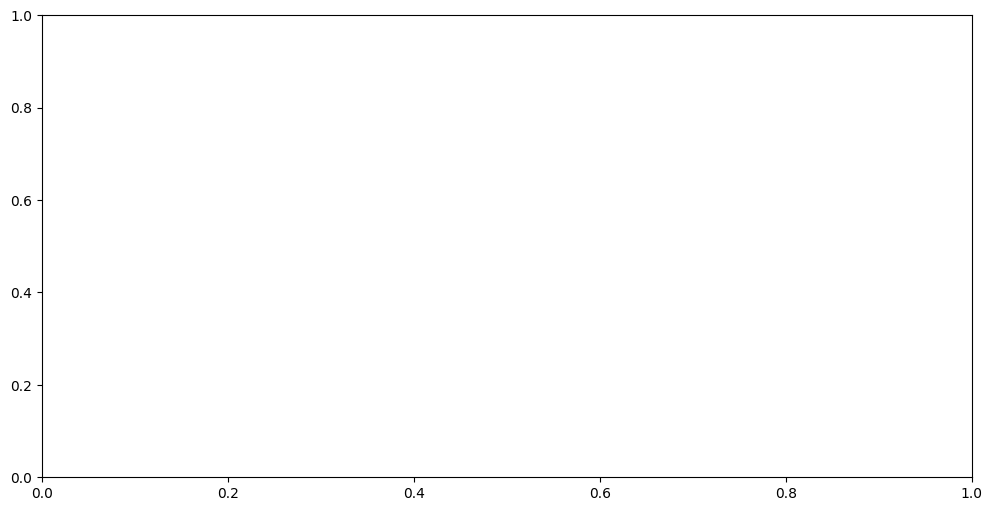

In [ ]:
device = embed_model.device

batch = next(iter(paired_dataloader))
x0, x1, _, _ = embed_model._prepare_batch(batch)

paths = embed_model.sample_geodesic_path(batch, num_points=50)
paths_flat = paths.reshape(-1, paths.shape[-1])

time_axis = np.linspace(0, 1, 50)

with torch.no_grad():
    logits = classifier_model(torch.tensor(paths_flat, device=device).float())
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    
probs = probs.reshape(paths.shape[0], paths.shape[1], -1) # [Batch, Time, Classes]

itos = adata.uns['itos']
cell_types = [itos[i] for i in range(len(itos))] + ["outlier"]

avg_probs = probs.mean(axis=0) # [Time, Classes]

fig, ax = plt.subplots(figsize=(12, 6))

print(paths.shape)
print(time_axis.shape)
print(probs.shape)
print(avg_probs.shape)

ax.stackplot(time_axis, avg_probs.T, labels=cell_types, alpha=0.8)

ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Predicted Cell Type")
ax.set_title(f"Average Cell Type Transition: {t0} -> {t1}")
ax.set_xlabel("Integration Time")
ax.set_ylabel("Class Probability")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
batch = next(iter(paired_dataloader))
paths = embed_model.sample_geodesic_path(batch, num_points=200)

start = paths[0,:30]
end = paths[-1,:30]
itos = adata.uns['itos']
start_classes = torch.argmax(classifier_model(start), dim=1).detach().cpu().numpy()
start_classes = [itos[i] for i in start_classes]
end_classes = torch.argmax(classifier_model(end), dim=1).detach().cpu().numpy()
end_classes = [itos[i] for i in end_classes]

for i in range(30):
    print(f"{start_classes[i]:<50} {end_classes[i]:>50}")


In [ ]:
#36->48->72
#TODO: reintroduce UOT with confirmation that it's working

#CFM: 15.929224967956543
#CFM + Finsler: 15.754395484924316

#MFM-Euc: 15.122610092163086
#MFM: 15.078815460205078
#MFM + Finsler: 15.24450969696045

In [ ]:
paths.shape

In [ ]:
import umap
import numpy as np
import matplotlib.pyplot as plt

X_data = adata.obsm['X_pca']

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.5, metric='euclidean') 
X_umap = umap_model.fit_transform(X_data)
adata.obsm['X_umap'] = X_umap

traj_umap = umap_model.transform(paths.reshape(-1, 100))
traj_umap = traj_umap.reshape((-1, 512, 2))

In [ ]:

import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=adata.obs['cell_type'], # Directly pass the categorical column
    s=10,
    ax=ax,
    palette='tab10', # Or use a specific palette
    edgecolor=None   # Removes outlines for a cleaner look
)
for i in range(3):
    plt.plot(traj_umap[:, i, 0], traj_umap[:,i, 1], c='red', linewidth=3, label='Learned Trajectory')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

plt.figure(figsize=(8,8))

